In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/final/final.csv")

In [3]:
df_clean = df[df["Playing_Time_90s"] >= 5]
df.drop_duplicates(subset=['player', 'season'], inplace=True)

## Age Curve Analysis

This section explores how player performance changes with age. Each figure below is a single-panel visualization with no subplots, designed to be clear enough for the notebook and polished enough for a poster.

Saved: ../../visualization_poster/age_curve_median_overall_rating.png


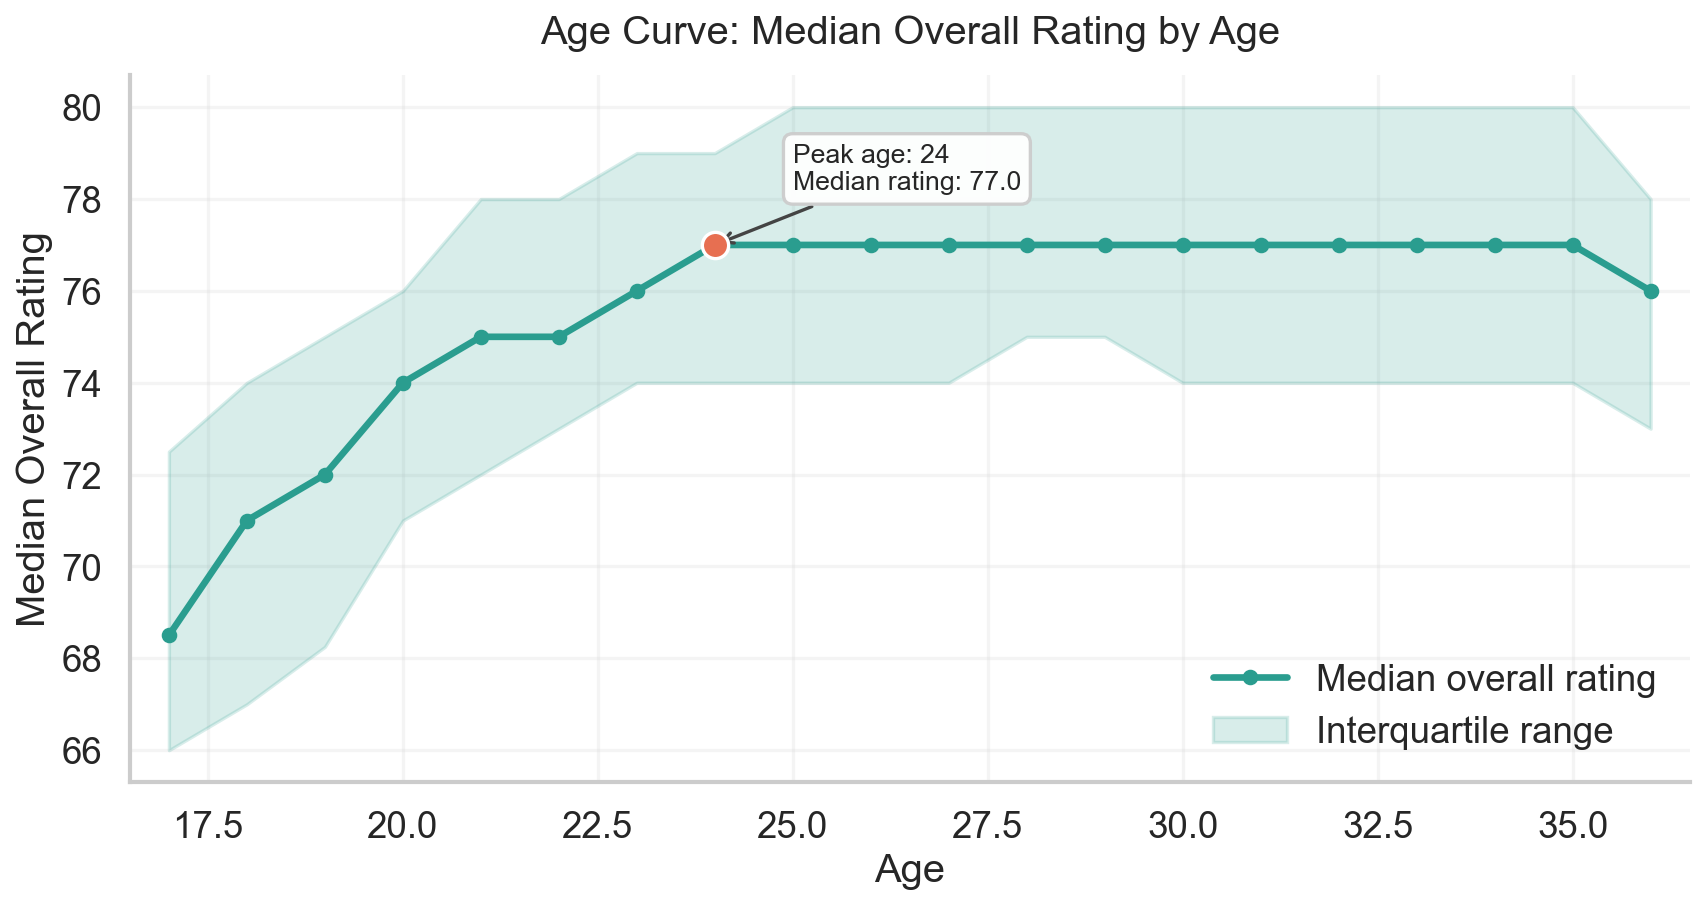

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")

SAVE_DIR = Path("../../visualization_poster")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename, fig=None):
    if fig is None:
        fig = plt.gcf()
    output_path = SAVE_DIR / f"{filename}.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")

age_summary = (
    df_clean.dropna(subset=["age", "overall_rating"])
.groupby("age")
    .agg(
        median_overall=("overall_rating", "median"),
        q25_overall=("overall_rating", lambda x: x.quantile(0.25)),
        q75_overall=("overall_rating", lambda x: x.quantile(0.75)),
        player_count=("overall_rating", "size")
    )
    .reset_index()
    .sort_values("age")
)
age_summary = age_summary[age_summary["player_count"] >= 20].copy()

peak_row = age_summary.loc[age_summary["median_overall"].idxmax()]
peak_age = int(peak_row["age"])
peak_value = float(peak_row["median_overall"])

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(
    age_summary["age"],
    age_summary["median_overall"],
    color="#2A9D8F",
    linewidth=3,
    marker="o",
    markersize=6,
    label="Median overall rating"
)
ax.fill_between(
    age_summary["age"],
    age_summary["q25_overall"],
    age_summary["q75_overall"],
    color="#2A9D8F",
    alpha=0.18,
    label="Interquartile range"
)
ax.scatter([peak_age], [peak_value], s=140, color="#E76F51", edgecolor="white", linewidth=1.5, zorder=5)
ax.annotate(
    f"Peak age: {peak_age}\nMedian rating: {peak_value:.1f}",
    xy=(peak_age, peak_value),
    xytext=(peak_age + 1, peak_value + 1.2),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#444"),
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#cccccc", alpha=0.95)
)
ax.set_title("Age Curve: Median Overall Rating by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Overall Rating")
ax.set_xlim(age_summary["age"].min() - 0.5, age_summary["age"].max() + 0.5)
ax.legend(frameon=False, loc="best")
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
save_plot("age_curve_median_overall_rating", fig)
plt.show()

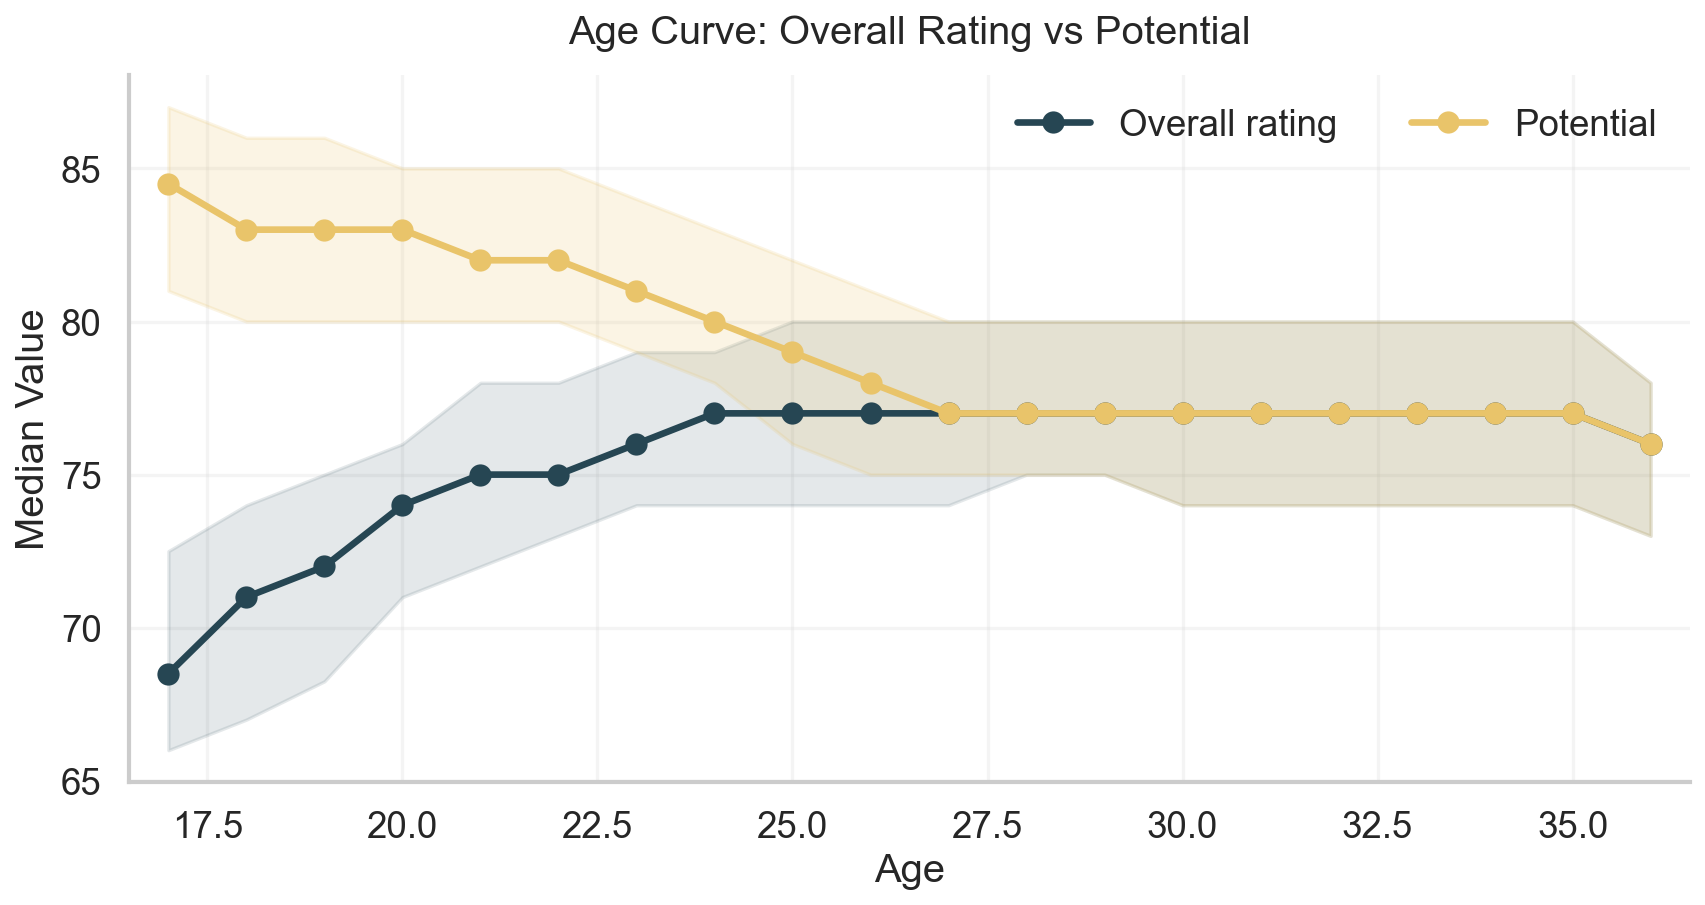

In [5]:
age_compare = (
    df_clean.dropna(subset=["age", "overall_rating", "potential"])
    .groupby("age")
    .agg(
        median_overall=("overall_rating", "median"),
        q25_overall=("overall_rating", lambda x: x.quantile(0.25)),
        q75_overall=("overall_rating", lambda x: x.quantile(0.75)),
        median_potential=("potential", "median"),
        q25_potential=("potential", lambda x: x.quantile(0.25)),
        q75_potential=("potential", lambda x: x.quantile(0.75)),
        player_count=("overall_rating", "size"),
    )
    .reset_index()
    .sort_values("age")
)
age_compare = age_compare[age_compare["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(age_compare["age"], age_compare["median_overall"], color="#264653", linewidth=3, marker="o", label="Overall rating")
ax.plot(age_compare["age"], age_compare["median_potential"], color="#E9C46A", linewidth=3, marker="o", label="Potential")
ax.fill_between(age_compare["age"], age_compare["q25_overall"], age_compare["q75_overall"], color="#264653", alpha=0.12)
ax.fill_between(age_compare["age"], age_compare["q25_potential"], age_compare["q75_potential"], color="#E9C46A", alpha=0.18)
ax.set_title("Age Curve: Overall Rating vs Potential", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Value")
ax.set_xlim(age_compare["age"].min() - 0.5, age_compare["age"].max() + 0.5)
ax.legend(frameon=False, ncol=2)
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

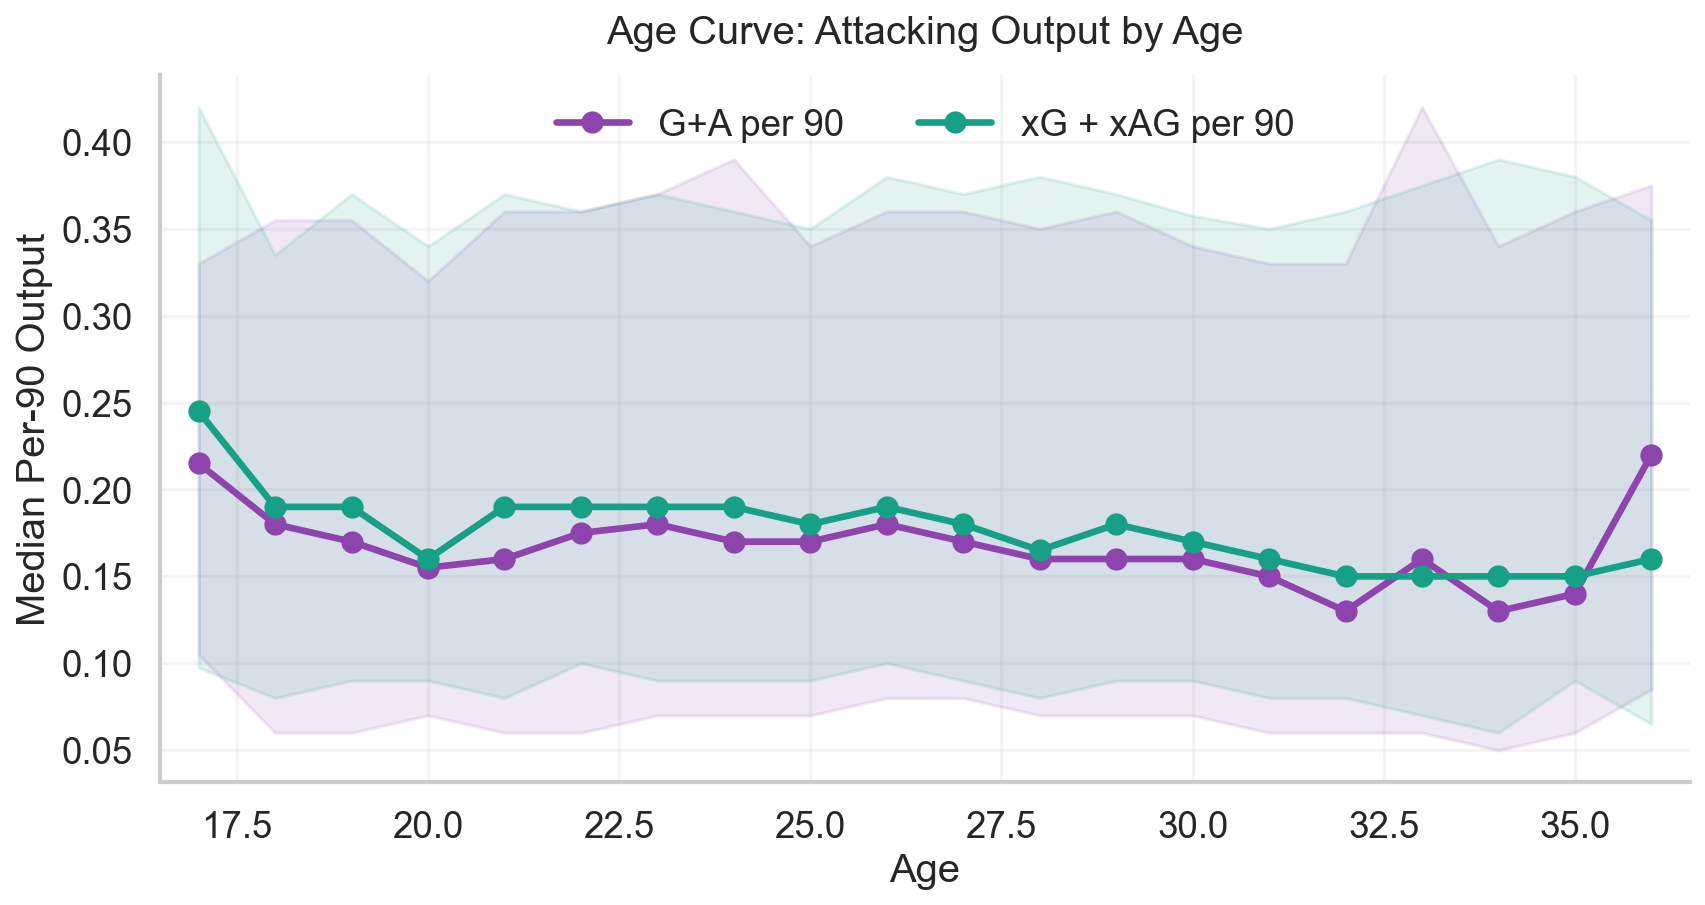

In [6]:
attack_age = (
    df_clean.dropna(subset=["age", "Per_90_Minutes_G+A", "Per_90_Minutes_xG+xAG"])
    .groupby("age")
    .agg(
        median_ga90=("Per_90_Minutes_G+A", "median"),
        q25_ga90=("Per_90_Minutes_G+A", lambda x: x.quantile(0.25)),
        q75_ga90=("Per_90_Minutes_G+A", lambda x: x.quantile(0.75)),
        median_xgxa=("Per_90_Minutes_xG+xAG", "median"),
        q25_xgxa=("Per_90_Minutes_xG+xAG", lambda x: x.quantile(0.25)),
        q75_xgxa=("Per_90_Minutes_xG+xAG", lambda x: x.quantile(0.75)),
        player_count=("Per_90_Minutes_G+A", "size"),
    )
    .reset_index()
    .sort_values("age")
)
attack_age = attack_age[attack_age["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(attack_age["age"], attack_age["median_ga90"], color="#8E44AD", linewidth=3, marker="o", label="G+A per 90")
ax.plot(attack_age["age"], attack_age["median_xgxa"], color="#16A085", linewidth=3, marker="o", label="xG + xAG per 90")
ax.fill_between(attack_age["age"], attack_age["q25_ga90"], attack_age["q75_ga90"], color="#8E44AD", alpha=0.12)
ax.fill_between(attack_age["age"], attack_age["q25_xgxa"], attack_age["q75_xgxa"], color="#16A085", alpha=0.12)
ax.set_title("Age Curve: Attacking Output by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Per-90 Output")
ax.set_xlim(attack_age["age"].min() - 0.5, attack_age["age"].max() + 0.5)
ax.legend(frameon=False, ncol=2)
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

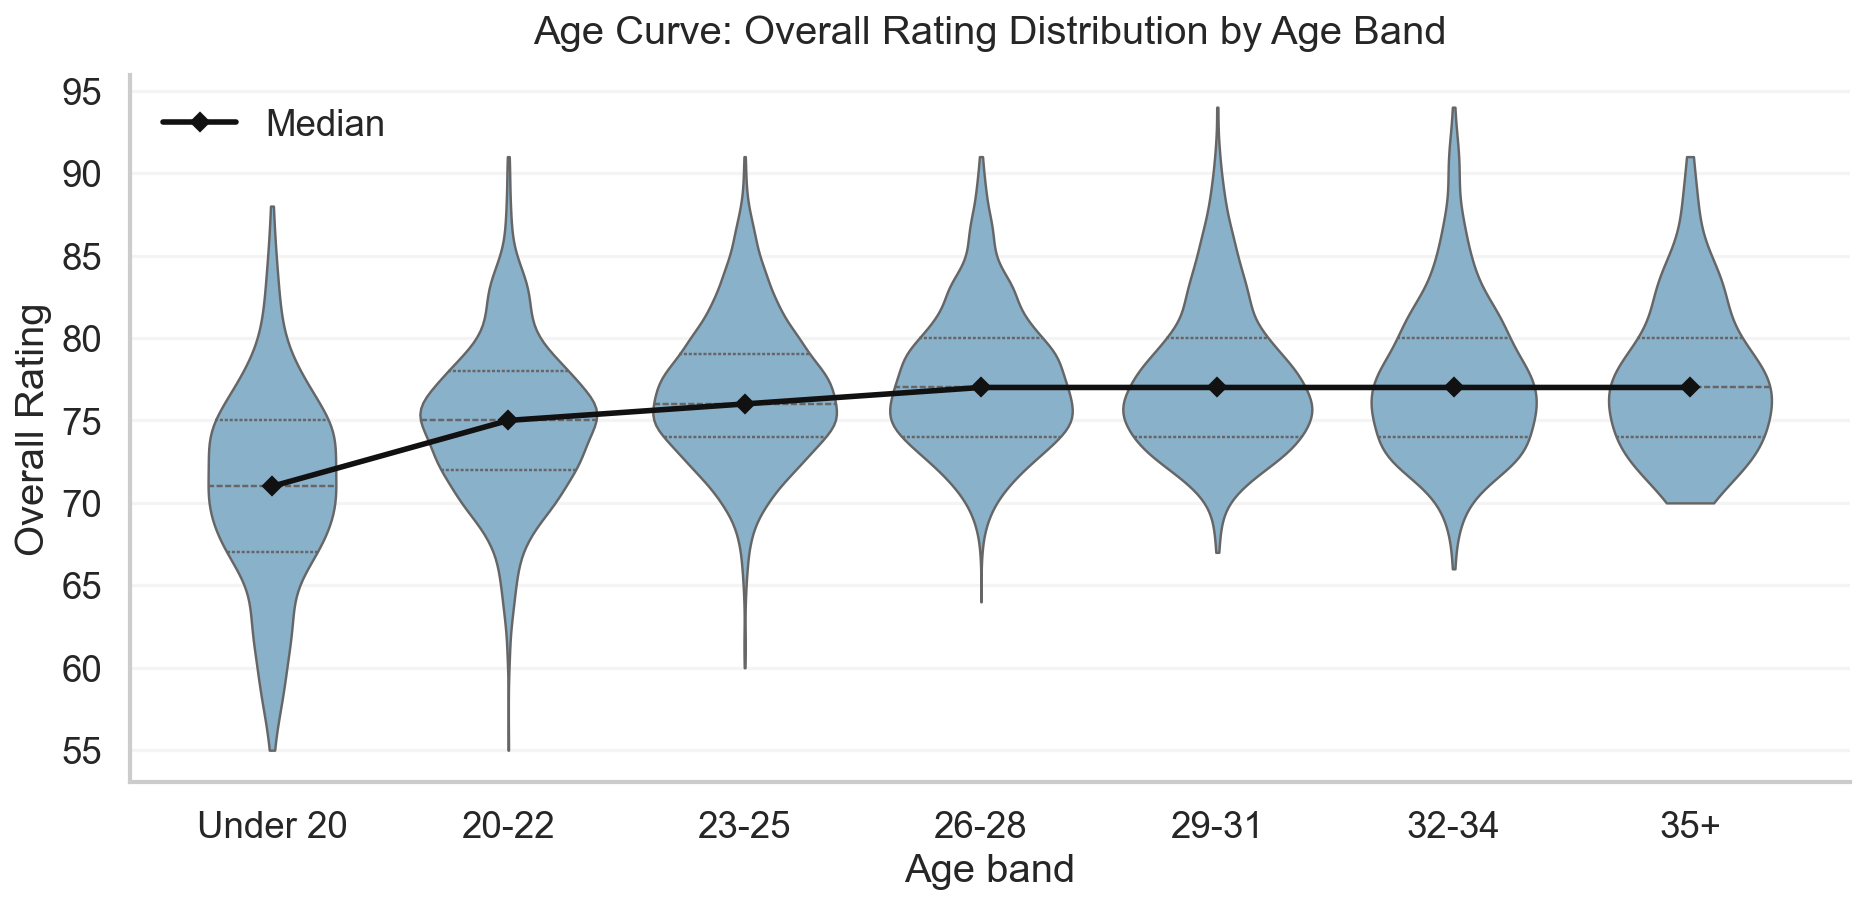

In [7]:
age_band_order = [
    "Under 20",
    "20-22",
    "23-25",
    "26-28",
    "29-31",
    "32-34",
    "35+"
]

def make_age_band(age):
    if age < 20:
        return "Under 20"
    elif age <= 22:
        return "20-22"
    elif age <= 25:
        return "23-25"
    elif age <= 28:
        return "26-28"
    elif age <= 31:
        return "29-31"
    elif age <= 34:
        return "32-34"
    return "35+"

band_df = df_clean.dropna(subset=["age", "overall_rating"]).copy()
band_df["age_band"] = band_df["age"].apply(make_age_band)
band_df["age_band"] = pd.Categorical(band_df["age_band"], categories=age_band_order, ordered=True)
median_by_band = band_df.groupby("age_band", observed=True)["overall_rating"].median().reindex(age_band_order)

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)
sns.violinplot(
    data=band_df,
    x="age_band",
    y="overall_rating",
    order=age_band_order,
    color="#7FB3D5",
    ax=ax,
    inner="quartile",
    cut=0,
    linewidth=1.1
)
ax.plot(range(len(age_band_order)), median_by_band.values, color="#111111", linewidth=2.5, marker="D", markersize=6, label="Median")
ax.set_title("Age Curve: Overall Rating Distribution by Age Band", pad=14)
ax.set_xlabel("Age band")
ax.set_ylabel("Overall Rating")
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False, loc="best")
sns.despine(ax=ax)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

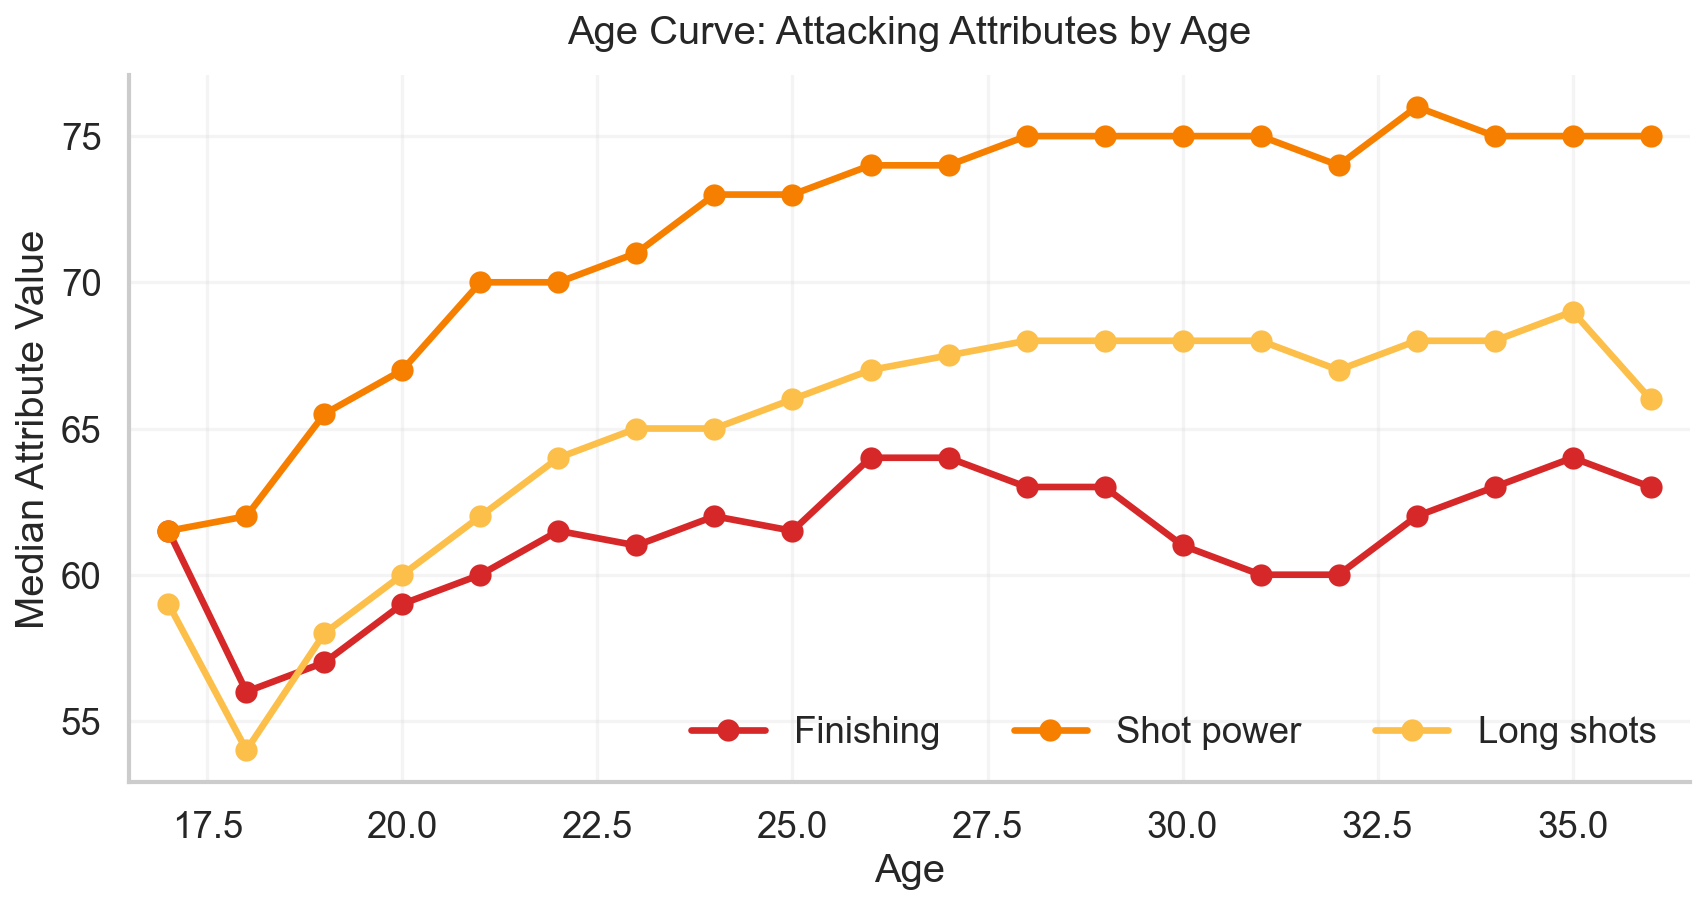

In [8]:
attack_attrs = (
    df_clean.dropna(subset=["age", "finishing", "shot_power", "long_shots"])
    .groupby("age")
    .agg(
        median_finishing=("finishing", "median"),
        median_shot_power=("shot_power", "median"),
        median_long_shots=("long_shots", "median"),
        player_count=("finishing", "size"),
    )
    .reset_index()
    .sort_values("age")
)
attack_attrs = attack_attrs[attack_attrs["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(attack_attrs["age"], attack_attrs["median_finishing"], color="#D62828", linewidth=3, marker="o", label="Finishing")
ax.plot(attack_attrs["age"], attack_attrs["median_shot_power"], color="#F77F00", linewidth=3, marker="o", label="Shot power")
ax.plot(attack_attrs["age"], attack_attrs["median_long_shots"], color="#FCBF49", linewidth=3, marker="o", label="Long shots")
ax.set_title("Age Curve: Attacking Attributes by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Attribute Value")
ax.set_xlim(attack_attrs["age"].min() - 0.5, attack_attrs["age"].max() + 0.5)
ax.legend(frameon=False, ncol=3)
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

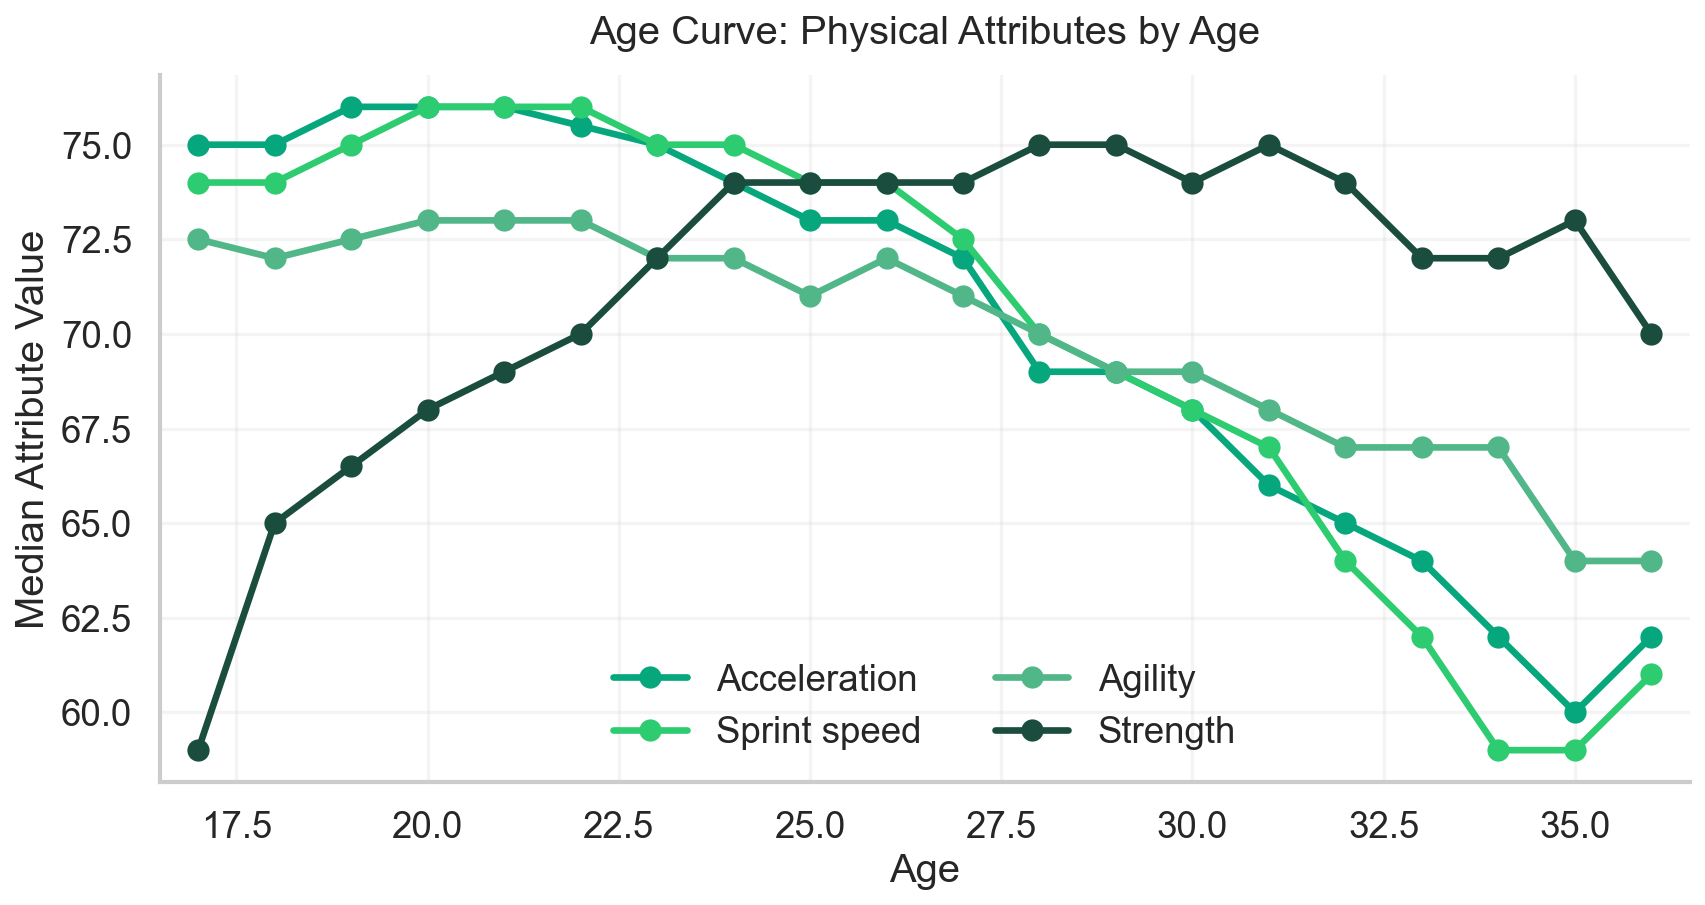

In [9]:
physical_attrs = (
    df_clean.dropna(subset=["age", "acceleration", "sprint_speed", "agility", "strength"])
    .groupby("age")
    .agg(
        median_accel=("acceleration", "median"),
        median_sprint=("sprint_speed", "median"),
        median_agility=("agility", "median"),
        median_strength=("strength", "median"),
        player_count=("acceleration", "size"),
    )
    .reset_index()
    .sort_values("age")
)
physical_attrs = physical_attrs[physical_attrs["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(physical_attrs["age"], physical_attrs["median_accel"], color="#06A77D", linewidth=3, marker="o", label="Acceleration")
ax.plot(physical_attrs["age"], physical_attrs["median_sprint"], color="#2ECC71", linewidth=3, marker="o", label="Sprint speed")
ax.plot(physical_attrs["age"], physical_attrs["median_agility"], color="#52B788", linewidth=3, marker="o", label="Agility")
ax.plot(physical_attrs["age"], physical_attrs["median_strength"], color="#1B4D3E", linewidth=3, marker="o", label="Strength")
ax.set_title("Age Curve: Physical Attributes by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Attribute Value")
ax.set_xlim(physical_attrs["age"].min() - 0.5, physical_attrs["age"].max() + 0.5)
ax.legend(frameon=False, ncol=2, loc="best")
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

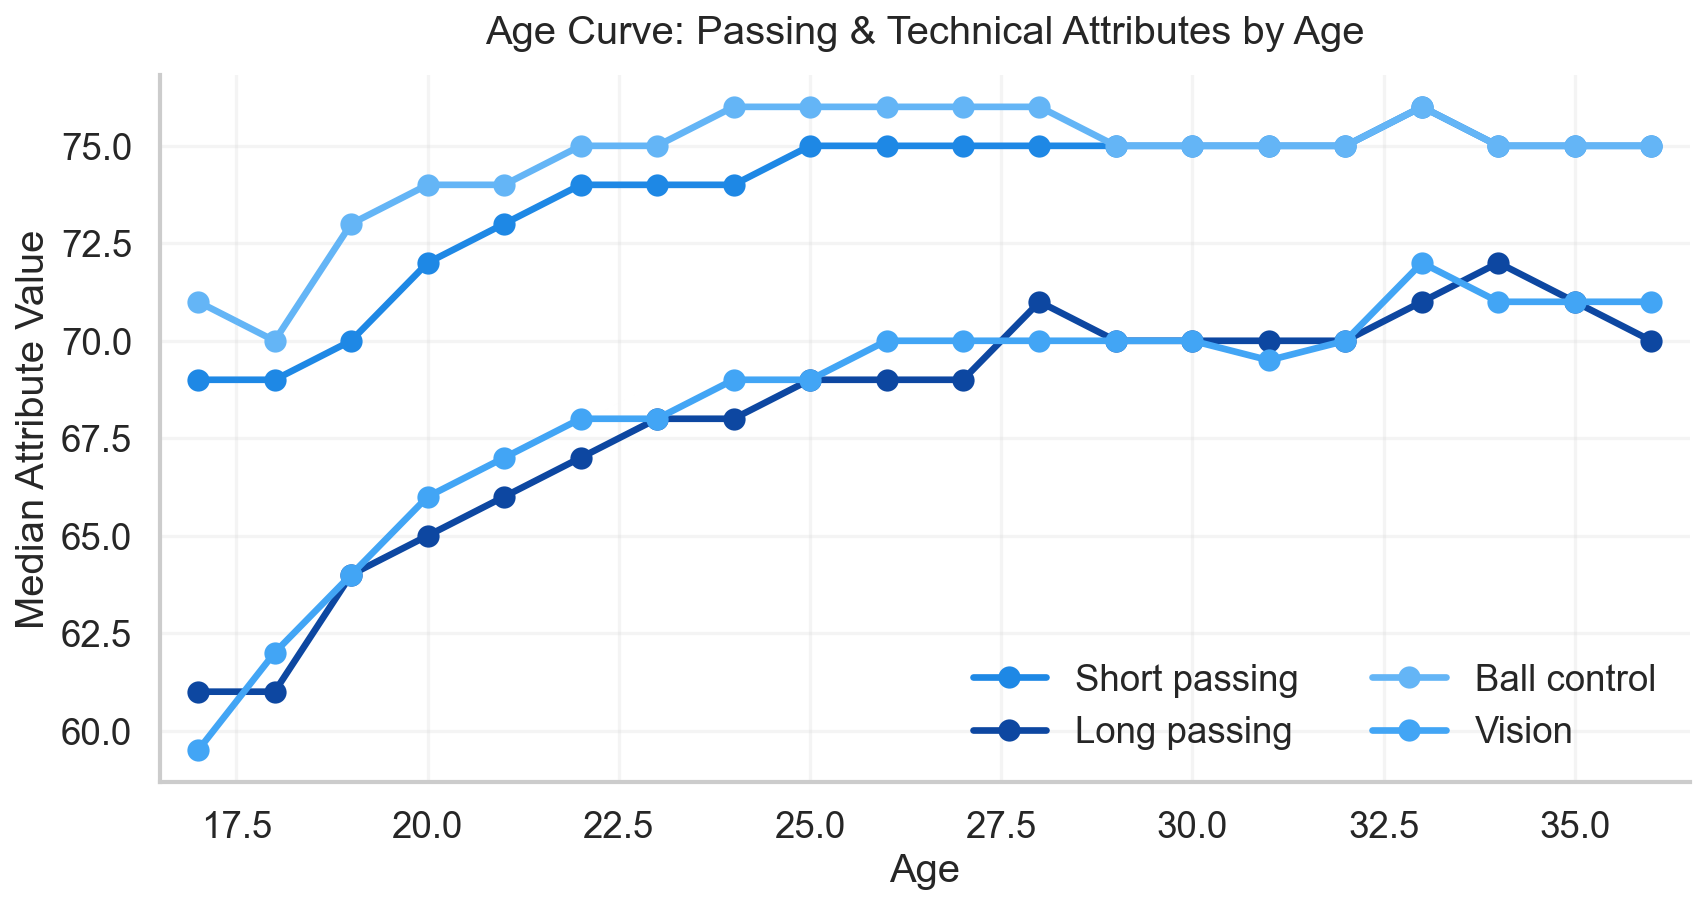

In [10]:
passing_attrs = (
    df_clean.dropna(subset=["age", "short_passing", "long_passing", "ball_control", "vision"])
    .groupby("age")
    .agg(
        median_short_pass=("short_passing", "median"),
        median_long_pass=("long_passing", "median"),
        median_ball_ctrl=("ball_control", "median"),
        median_vision=("vision", "median"),
        player_count=("short_passing", "size"),
    )
    .reset_index()
    .sort_values("age")
)
passing_attrs = passing_attrs[passing_attrs["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(passing_attrs["age"], passing_attrs["median_short_pass"], color="#1E88E5", linewidth=3, marker="o", label="Short passing")
ax.plot(passing_attrs["age"], passing_attrs["median_long_pass"], color="#0D47A1", linewidth=3, marker="o", label="Long passing")
ax.plot(passing_attrs["age"], passing_attrs["median_ball_ctrl"], color="#64B5F6", linewidth=3, marker="o", label="Ball control")
ax.plot(passing_attrs["age"], passing_attrs["median_vision"], color="#42A5F5", linewidth=3, marker="o", label="Vision")
ax.set_title("Age Curve: Passing & Technical Attributes by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Attribute Value")
ax.set_xlim(passing_attrs["age"].min() - 0.5, passing_attrs["age"].max() + 0.5)
ax.legend(frameon=False, ncol=2, loc="best")
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

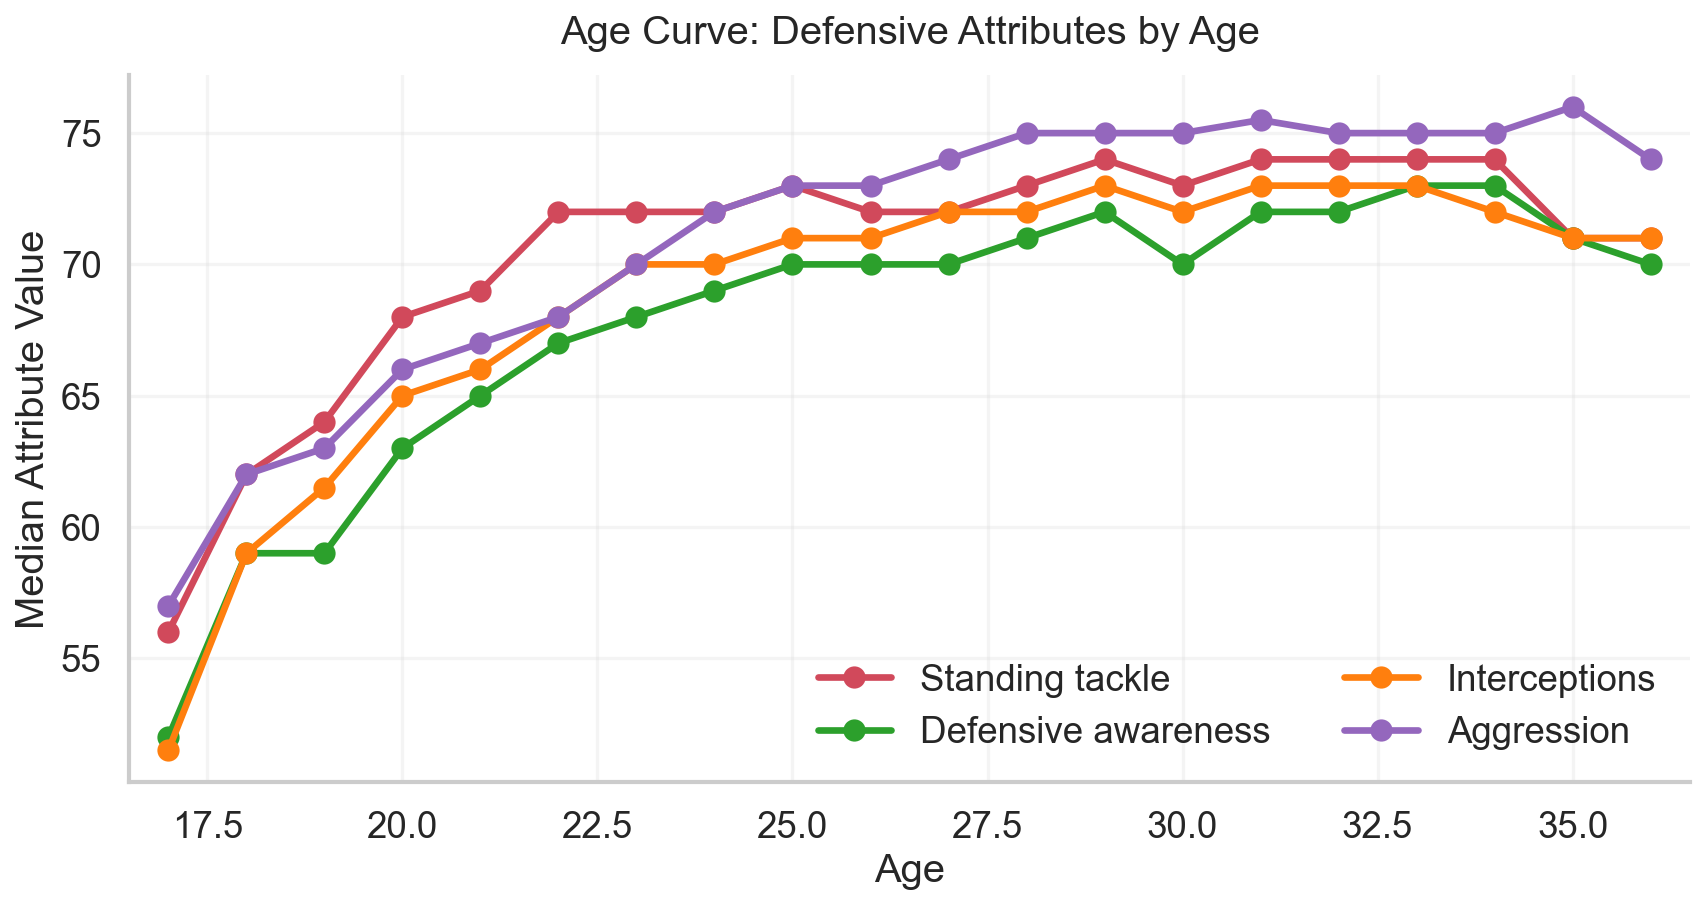

In [11]:
defending_attrs = (
    df_clean.dropna(subset=["age", "standing_tackle", "defensive_awareness", "interceptions", "aggression"])
    .groupby("age")
    .agg(
        median_tackle=("standing_tackle", "median"),
        median_def_aware=("defensive_awareness", "median"),
        median_intercept=("interceptions", "median"),
        median_aggression=("aggression", "median"),
        player_count=("standing_tackle", "size"),
    )
    .reset_index()
    .sort_values("age")
)
defending_attrs = defending_attrs[defending_attrs["player_count"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 6), dpi=160)
ax.plot(defending_attrs["age"], defending_attrs["median_tackle"], color="#D1495B", linewidth=3, marker="o", label="Standing tackle")
ax.plot(defending_attrs["age"], defending_attrs["median_def_aware"], color="#2CA02C", linewidth=3, marker="o", label="Defensive awareness")
ax.plot(defending_attrs["age"], defending_attrs["median_intercept"], color="#FF7F0E", linewidth=3, marker="o", label="Interceptions")
ax.plot(defending_attrs["age"], defending_attrs["median_aggression"], color="#9467BD", linewidth=3, marker="o", label="Aggression")
ax.set_title("Age Curve: Defensive Attributes by Age", pad=14)
ax.set_xlabel("Age")
ax.set_ylabel("Median Attribute Value")
ax.set_xlim(defending_attrs["age"].min() - 0.5, defending_attrs["age"].max() + 0.5)
ax.legend(frameon=False, ncol=2, loc="best")
sns.despine(ax=ax)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()